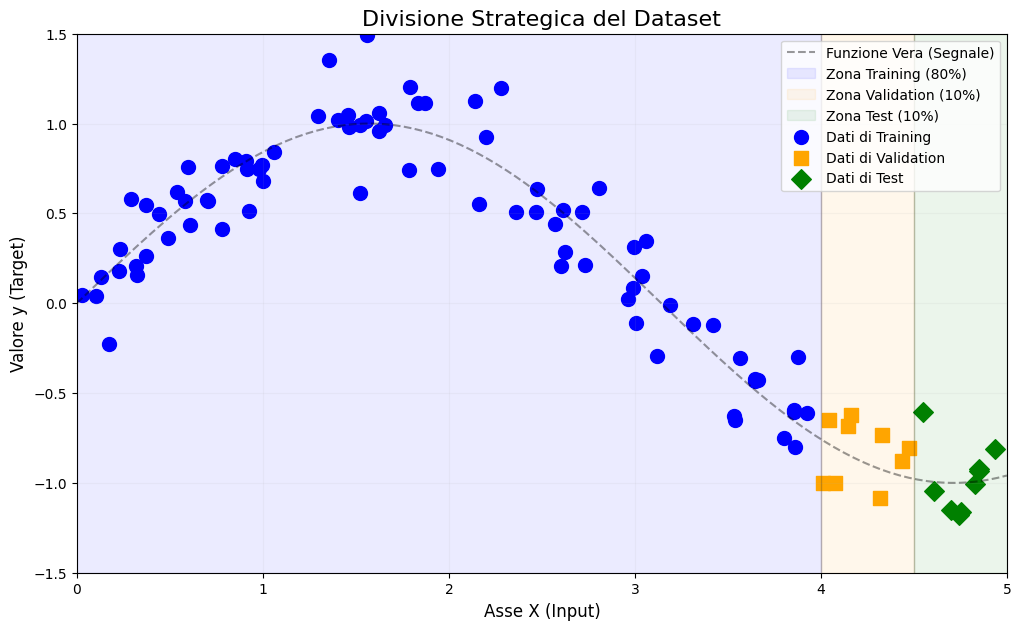

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generazione del Dataset (20 punti)
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.rand(n_samples) * 5) # Generiamo X tra 0 e 5
y_true = np.sin(X)
y_noisy = y_true + np.random.randn(n_samples) * 0.2 # Aggiungiamo rumore

# 2. Definizione dei limiti di divisione (80% - 10% - 10%)
# Range totale = 5.0 -> Train: [0,4], Val: [4, 4.5], Test: [4.5, 5]
split_train = 4.0
split_val = 4.5

# 3. Creazione del Grafico
plt.figure(figsize=(12, 7))

# Curva sinusoidale pura (Ground Truth)
X_plot = np.linspace(0, 5, 200)
plt.plot(X_plot, np.sin(X_plot), color='black', linestyle='--', alpha=0.4, label='Funzione Vera (Segnale)')

# Aree colorate di sfondo per indicare la divisione dell'asse X
plt.axvspan(0, split_train, color='blue', alpha=0.08, label='Zona Training (80%)')
plt.axvspan(split_train, split_val, color='orange', alpha=0.08, label='Zona Validation (10%)')
plt.axvspan(split_val, 5, color='green', alpha=0.08, label='Zona Test (10%)')

# Punti del dataset divisi per set
# Training
mask_train = X <= split_train
plt.scatter(X[mask_train], y_noisy[mask_train], color='blue', s=100, label='Dati di Training')

# Validation
mask_val = (X > split_train) & (X <= split_val)
plt.scatter(X[mask_val], y_noisy[mask_val], color='orange', s=100, marker='s', label='Dati di Validation')

# Test
mask_test = X > split_val
plt.scatter(X[mask_test], y_noisy[mask_test], color='green', s=100, marker='D', label='Dati di Test')

# Linee di confine verticali
plt.axvline(split_train, color='black', lw=1, alpha=0.2)
plt.axvline(split_val, color='black', lw=1, alpha=0.2)

# Estetica e testi
plt.title('Divisione Strategica del Dataset', fontsize=16)
plt.xlabel('Asse X (Input)', fontsize=12)
plt.ylabel('Valore y (Target)', fontsize=12)
plt.ylim(-1.5, 1.5)
plt.xlim(0, 5)
plt.legend(loc='upper right', frameon=True, fontsize=10)
plt.grid(True, alpha=0.1)

# Salvataggio per le slide
plt.savefig('split_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

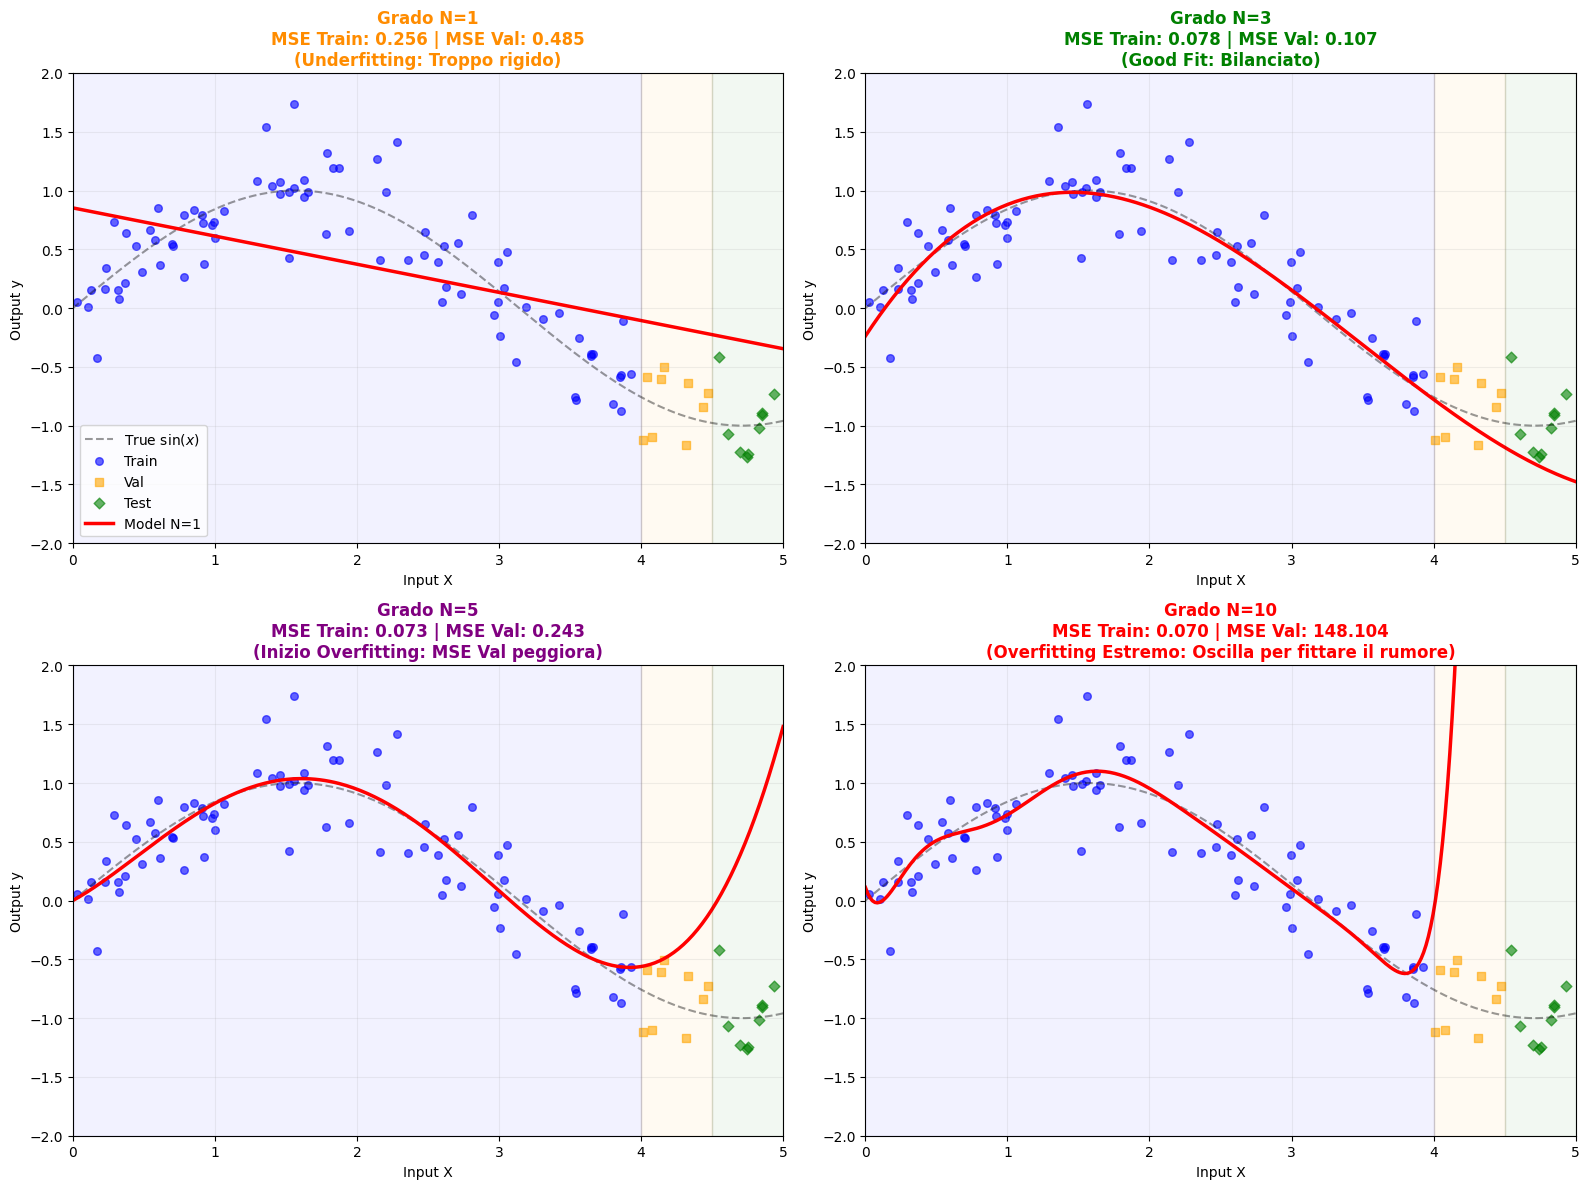

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# --- 1. Setup Dati e Divisione ---
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.rand(n_samples) * 5) # X tra 0 e 5
y_true = np.sin(X)
y_noisy = y_true + np.random.randn(n_samples) * 0.3 # Rumore leggermente aumentato per 100 punti

# Divisione 80% - 10% - 10% su X da 0 a 5
split_train = 4.0
split_val = 4.5

# Maschere Boolean
mask_train = X <= split_train
mask_val = (X > split_train) & (X <= split_val)
mask_test = X > split_val

# Dataset divisi
X_train, y_train = X[mask_train], y_noisy[mask_train]
X_val, y_val = X[mask_val], y_noisy[mask_val]
X_test, y_test = X[mask_test], y_noisy[mask_test]

# Reshape per sklearn
X_train_sk = X_train[:, np.newaxis]
X_val_sk = X_val[:, np.newaxis]

# Asse X denso per il plotting delle curve
X_plot = np.linspace(0, 5, 300)[:, np.newaxis]

# --- 2. Configurazione Grafico ---
degrees = [1, 3, 5, 10]
plt.figure(figsize=(16, 12))

# --- 3. Loop Principale sui Gradi ---
for i, degree in enumerate(degrees):
    ax = plt.subplot(2, 2, i + 1)

    # --- A) Disegno Elementi Base (Sfondo, Dati, Funzione Vera) ---
    # Aree di background
    ax.axvspan(0, split_train, color='blue', alpha=0.05)
    ax.axvspan(split_train, split_val, color='orange', alpha=0.05)
    ax.axvspan(split_val, 5, color='green', alpha=0.05)

    # Funzione vera
    ax.plot(X_plot, np.sin(X_plot), color='black', linestyle='--', alpha=0.4, label='True $\sin(x)$' if i==0 else "")

    # Punti dati
    ax.scatter(X_train, y_train, color='blue', s=30, alpha=0.6, label='Train' if i==0 else "")
    ax.scatter(X_val, y_val, color='orange', s=30, marker='s', alpha=0.6, label='Val' if i==0 else "")
    ax.scatter(X_test, y_test, color='green', s=30, marker='D', alpha=0.6, label='Test' if i==0 else "")

    # --- B) Modellazione e Fitting (SOLO SUL TRAINING SET) ---
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False),
                          LinearRegression())
    model.fit(X_train_sk, y_train)

    # Predizioni per la curva e per le metriche
    y_plot = model.predict(X_plot)
    y_pred_train = model.predict(X_train_sk)
    y_pred_val = model.predict(X_val_sk)

    # --- C) Calcolo Metriche ---
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_val = mean_squared_error(y_val, y_pred_val)

    # --- D) Disegno Modello e Titoli ---
    ax.plot(X_plot, y_plot, color='red', linewidth=2.5, label=f'Model N={degree}' if i==0 else "")

    # Titolo dinamico con metriche
    title_text = f"Grado N={degree}\nMSE Train: {mse_train:.3f} | MSE Val: {mse_val:.3f}"

    # Aggiunta commenti didattici nel titolo
    if degree == 1:
        status = "(Underfitting: Troppo rigido)"
        color_status = 'darkorange'
    elif degree == 3:
        status = "(Good Fit: Bilanciato)"
        color_status = 'green'
    elif degree == 5:
        status = "(Inizio Overfitting: MSE Val peggiora)"
        color_status = 'purple'
    elif degree == 10:
        status = "(Overfitting Estremo: Oscilla per fittare il rumore)"
        color_status = 'red'

    ax.set_title(title_text + "\n" + status, color=color_status, fontsize=12, fontweight='bold')

    # --- E) Rifiniture Grafico ---
    ax.set_ylim(-2, 2)
    ax.set_xlim(0, 5)
    ax.set_xlabel("Input X")
    ax.set_ylabel("Output y")
    ax.grid(True, alpha=0.2)

    # Legenda solo nel primo grafico
    if i == 0:
        ax.legend(loc='lower left', frameon=True)
    
    # Linee di separazione verticali
    ax.axvline(split_train, color='black', lw=1, alpha=0.1)
    ax.axvline(split_val, color='black', lw=1, alpha=0.1)

plt.tight_layout()
plt.savefig("overfitting_polynomial_split.png", dpi=300) # Scommenta per salvare
plt.show()

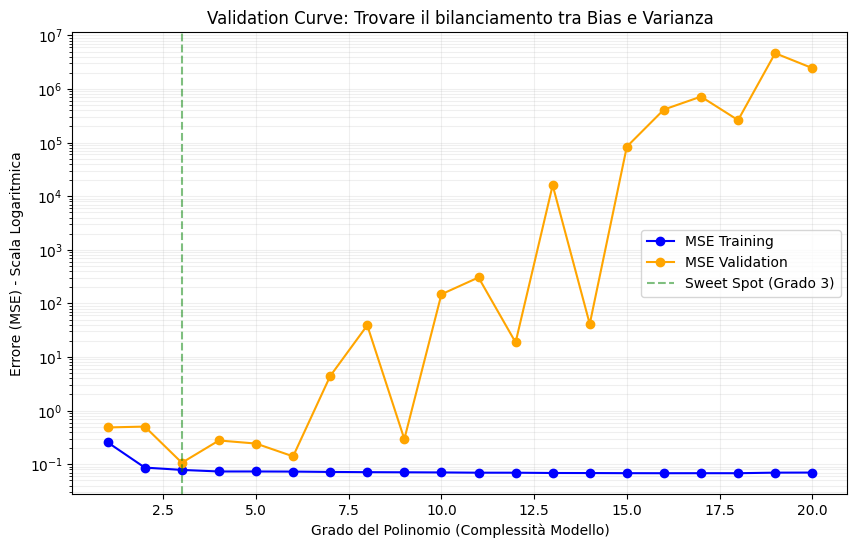

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 1. Preparazione range di complessità
degrees = np.arange(1, 21)
train_errors = []
val_errors = []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train[:, np.newaxis], y_train)
    
    # Calcolo errori
    train_errors.append(mean_squared_error(y_train, model.predict(X_train[:, np.newaxis])))
    val_errors.append(mean_squared_error(y_val, model.predict(X_val[:, np.newaxis])))

# 2. Visualizzazione
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='MSE Training', marker='o', color='blue')
plt.plot(degrees, val_errors, label='MSE Validation', marker='o', color='orange')

# Evidenziamo il punto di ottimo
best_deg = degrees[np.argmin(val_errors)]
plt.axvline(best_deg, linestyle='--', color='green', alpha=0.5, label=f'Sweet Spot (Grado {best_deg})')

plt.yscale('log') # Usiamo scala logaritmica per vedere meglio i salti
plt.xlabel('Grado del Polinomio (Complessità Modello)')
plt.ylabel('Errore (MSE) - Scala Logaritmica')
plt.title('Validation Curve: Trovare il bilanciamento tra Bias e Varianza')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("overfitting_polynomial_split_diagram.png", dpi=300) # Scommenta per salvare

plt.show()

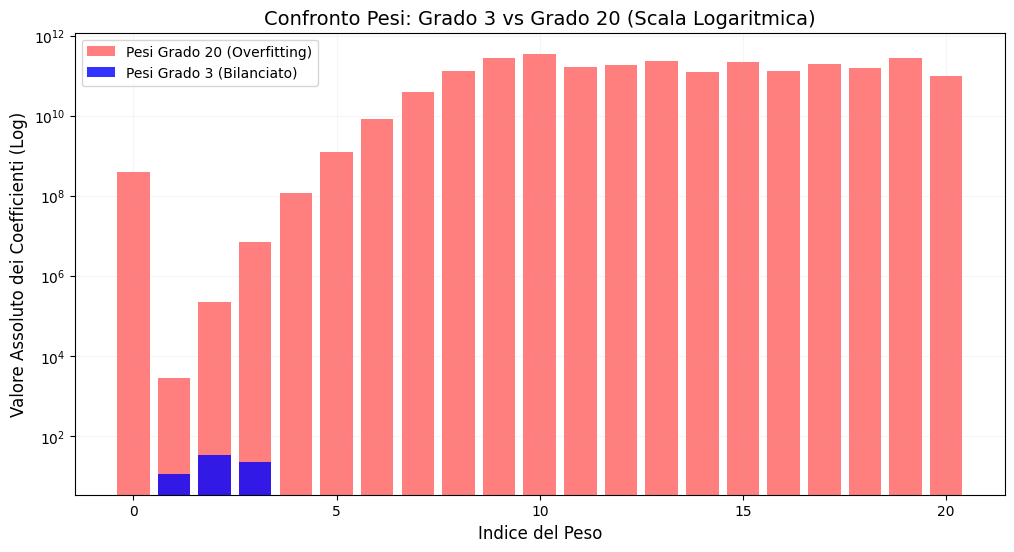

Max Peso Grado 3:  34.23
Max Peso Grado 20: 3.53e+11


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Generazione dati (20 punti in range 0-1)
np.random.seed(1)
X = np.sort(np.random.uniform(0, 1, 20))
y = np.sin(2 * np.pi * X) + np.random.randn(20) * 0.1
X_train = X[:, np.newaxis]

# 2. Addestramento dei modelli
model_3 = make_pipeline(PolynomialFeatures(3), LinearRegression())
model_3.fit(X_train, y)
w3 = model_3.named_steps['linearregression'].coef_

model_20 = make_pipeline(PolynomialFeatures(20), LinearRegression())
model_20.fit(X_train, y)
w20 = model_20.named_steps['linearregression'].coef_

# 3. Visualizzazione con Scala Logaritmica
plt.figure(figsize=(12, 6))

# Pesi Grado 20 (Barre Rosse)
plt.bar(range(len(w20)), np.abs(w20), color='red', alpha=0.5, label='Pesi Grado 20 (Overfitting)')
# Pesi Grado 3 (Barre Blu)
plt.bar(range(len(w3)), np.abs(w3), color='blue', alpha=0.8, label='Pesi Grado 3 (Bilanciato)')

plt.yscale('log') # Fondamentale: trasforma l'asse Y in scala logaritmica
plt.title("Confronto Pesi: Grado 3 vs Grado 20 (Scala Logaritmica)", fontsize=14)
plt.ylabel("Valore Assoluto dei Coefficienti (Log)", fontsize=12)
plt.xlabel("Indice del Peso", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.1)

plt.savefig('esplosione_pesi_log.png', dpi=300)
plt.show()

print(f"Max Peso Grado 3:  {np.max(np.abs(w3)):.2f}")
print(f"Max Peso Grado 20: {np.max(np.abs(w20)):.2e}")

C:\Users\adeangelis\PycharmProjects\corso\venv\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.84922e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


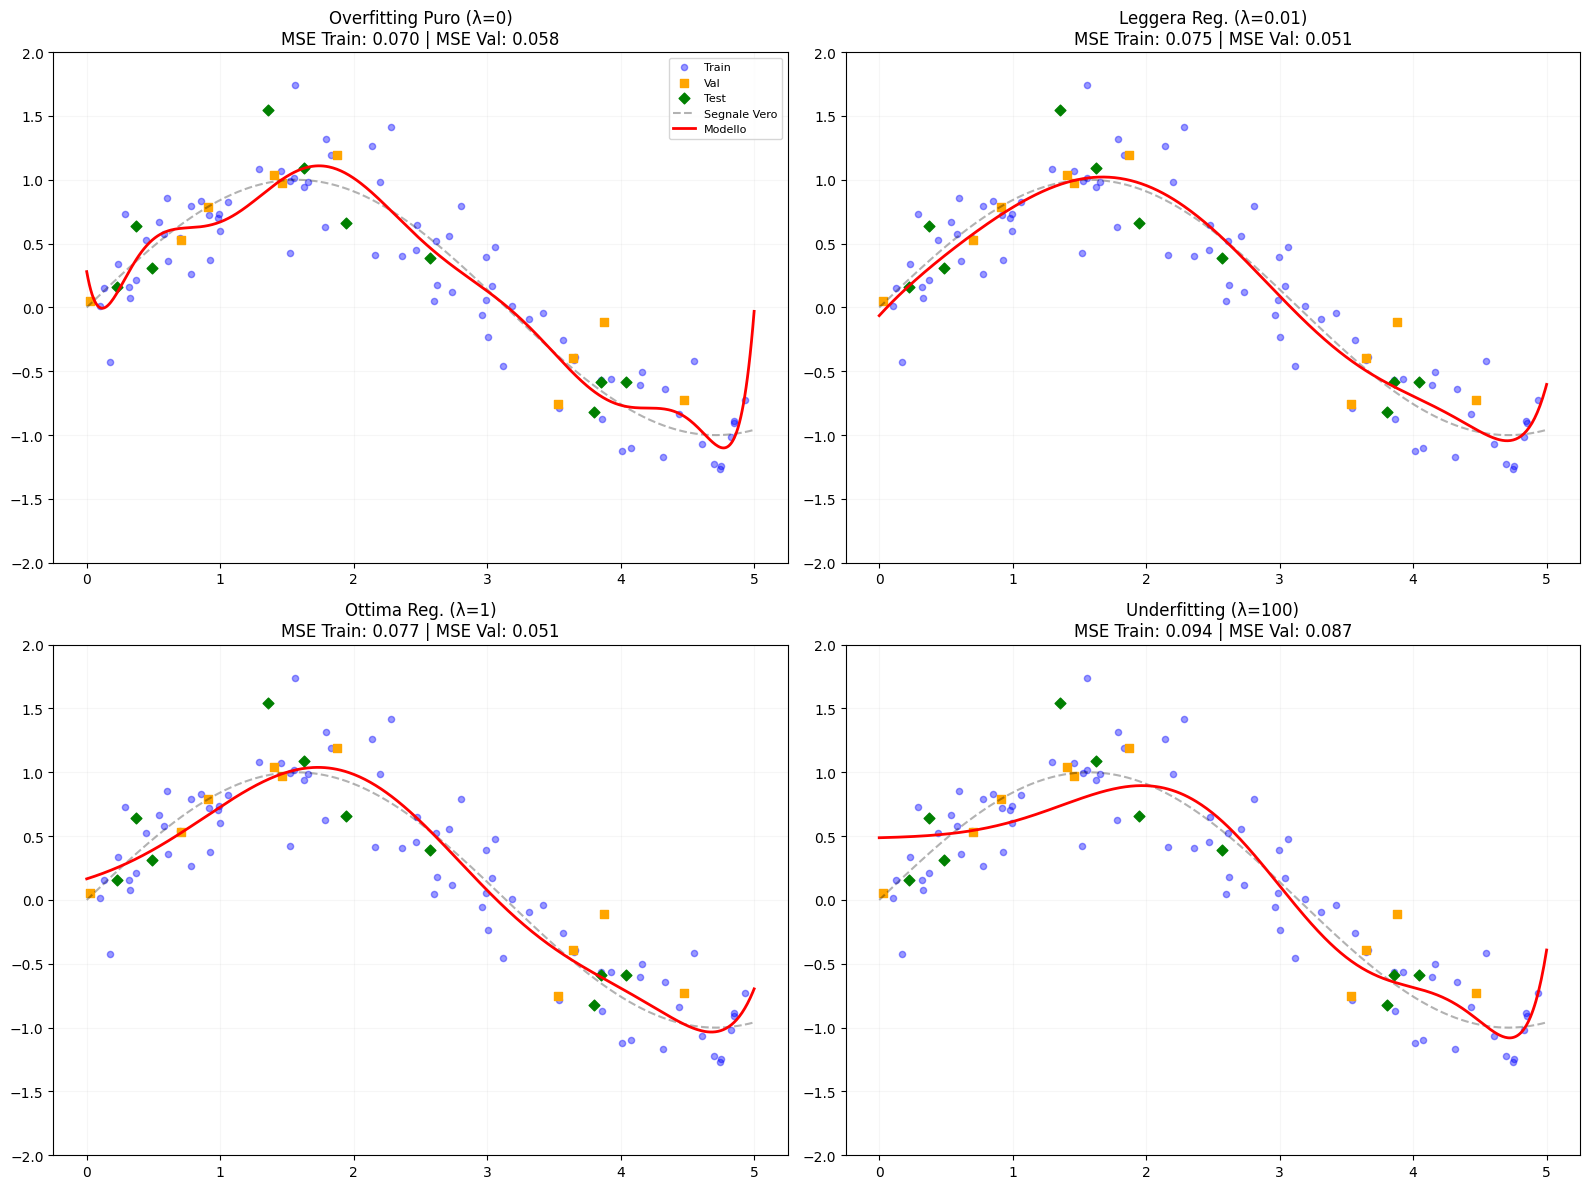

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

# 1. Generazione dati (100 punti mescolati)
np.random.seed(42)
X = np.sort(np.random.uniform(0, 5, 100))
y_true = np.sin(X)
y = y_true + np.random.randn(100) * 0.3

# 2. SUDDIVISIONE CASUALE (Shuffled Split)
# Dividiamo prima in Train (80%) e Resto (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
# Dividiamo il Resto in Validation (10%) e Test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# X per il disegno della curva (tutto il range)
X_plot = np.linspace(0, 5, 500)[:, np.newaxis]

# 3. Grafici comparativi
degree = 10
alphas = [0, 0.01, 1, 100] # Lambda: da zero a molto alto
titles = ["Overfitting Puro (λ=0)", "Leggera Reg. (λ=0.01)", "Ottima Reg. (λ=1)", "Underfitting (λ=100)"]

plt.figure(figsize=(16, 12))

for i, alpha in enumerate(alphas):
    ax = plt.subplot(2, 2, i + 1)
    
    # Scegliamo LinearRegression se alpha=0, altrimenti Ridge
    if alpha == 0:
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    else:
        model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha))
    
    model.fit(X_train[:, np.newaxis], y_train)
    y_pred_plot = model.predict(X_plot)
    
    # Calcolo MSE per Training e Validation
    mse_t = mean_squared_error(y_train, model.predict(X_train[:, np.newaxis]))
    mse_v = mean_squared_error(y_val, model.predict(X_val[:, np.newaxis]))

    # Plot dei punti (ora sono mescolati sull'asse X)
    ax.scatter(X_train, y_train, color='blue', s=20, alpha=0.4, label='Train')
    ax.scatter(X_val, y_val, color='orange', s=30, marker='s', label='Val')
    ax.scatter(X_test, y_test, color='green', s=30, marker='D', label='Test')
    
    # Plot curve
    ax.plot(X_plot, np.sin(X_plot), color='black', ls='--', alpha=0.3, label='Segnale Vero')
    ax.plot(X_plot, y_pred_plot, color='red', lw=2, label='Modello')
    
    ax.set_title(f"{titles[i]}\nMSE Train: {mse_t:.3f} | MSE Val: {mse_v:.3f}")
    ax.set_ylim(-2, 2)
    ax.grid(True, alpha=0.1)
    if i == 0: ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('regularization.png')
plt.show()